# 🌧️ Rain in Australia — EDA, Nettoyage & Feature Engineering

**Dataset :** [Kaggle — Weather Dataset Rattle Package](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)  
**Objectif :** Prédire `RainTomorrow` (variable cible binaire) à partir de ~23 variables météorologiques journalières.

---
### Plan
1. Chargement & aperçu général
2. Analyse exploratoire (EDA)
3. Traitement des valeurs manquantes
4. Feature Engineering
5. Dataset final prêt pour la modélisation

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path

# ── Style global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = {'No': '#4C9BE8', 'Yes': '#E05C5C'}
print('✅ Librairies chargées')

✅ Librairies chargées


---
## 1. Chargement des données

In [10]:
# ── Chargement ────────────────────────────────────────────────────────────────
# Mettez le chemin vers votre fichier CSV Kaggle ici
import kagglehub

CSV_PATH = 'weatherAUS.csv'   

if Path(CSV_PATH).exists():
    print("Path to dataset files:",path)
    df = pd.read_csv(CSV_PATH)
else : 

    # Download latest version
    path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
    print("Path to dataset files:", path)
    df = pd.read_csv(path+"/weatherAUS.csv")

df['Date'] = pd.to_datetime(df['Date'])

print(f"Dimensions        : {df.shape[0]:,} lignes  ×  {df.shape[1]} colonnes")
print(f"Période           : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Stations (Location): {df['Location'].nunique()} villes")
df.head(3)

Path to dataset files: /home/limam/.cache/kagglehub/datasets/jsphyg/weather-dataset-rattle-package/versions/2
Dimensions        : 145,460 lignes  ×  23 colonnes
Période           : 2007-11-01  →  2017-06-25
Stations (Location): 49 villes


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [11]:
# ── Types & mémoire ───────────────────────────────────────────────────────────
info = pd.DataFrame({
    'Dtype'   : df.dtypes,
    'Non-Null': df.notna().sum(),
    'Missing' : df.isna().sum(),
    'Miss %'  : (df.isna().mean() * 100).round(2),
    'Unique'  : df.nunique(),
})
info.sort_values('Miss %', ascending=False)

,Dtype,Non-Null,Missing,Miss %,Unique
Sunshine,float64,75625,69835,48.01,145
Evaporation,float64,82670,62790,43.17,358
Cloud3pm,float64,86102,59358,40.81,10
Cloud9am,float64,89572,55888,38.42,10
Pressure9am,float64,130395,15065,10.36,546
Pressure3pm,float64,130432,15028,10.33,549
WindDir9am,object,134894,10566,7.26,16
WindGustDir,object,135134,10326,7.10,16
WindGustSpeed,float64,135197,10263,7.06,67
Humidity3pm,float64,140953,4507,3.10,101


---
## 2. Analyse Exploratoire (EDA)

### 2.1 Distribution de la variable cible

In [12]:
import os
if not Path("artifacts").is_dir():
    os.mkdir("artifacts")

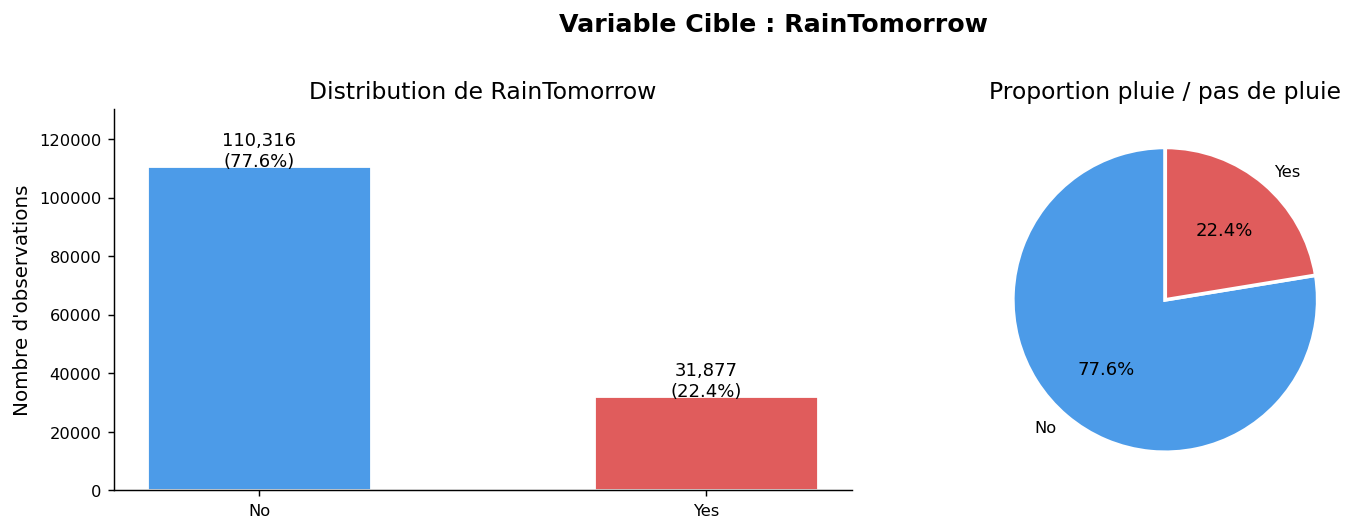

⚠️  Déséquilibre des classes : ratio No/Yes = 3.46  (classes imbalancées)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
counts = df['RainTomorrow'].value_counts(dropna=True)
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[k] for k in counts.index], width=0.5, edgecolor='white')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                 f'{v:,}\n({v/counts.sum()*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Distribution de RainTomorrow')
axes[0].set_ylabel('Nombre d\'observations')
axes[0].set_ylim(0, counts.max() * 1.18)

# Pie
axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[k] for k in counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proportion pluie / pas de pluie')

fig.suptitle('Variable Cible : RainTomorrow', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('artifacts/fig_target.png', bbox_inches='tight')
plt.show()

ratio = counts['No'] / counts['Yes']
print(f"⚠️  Déséquilibre des classes : ratio No/Yes = {ratio:.2f}  (classes imbalancées)")

### 2.2 Carte thermique des valeurs manquantes

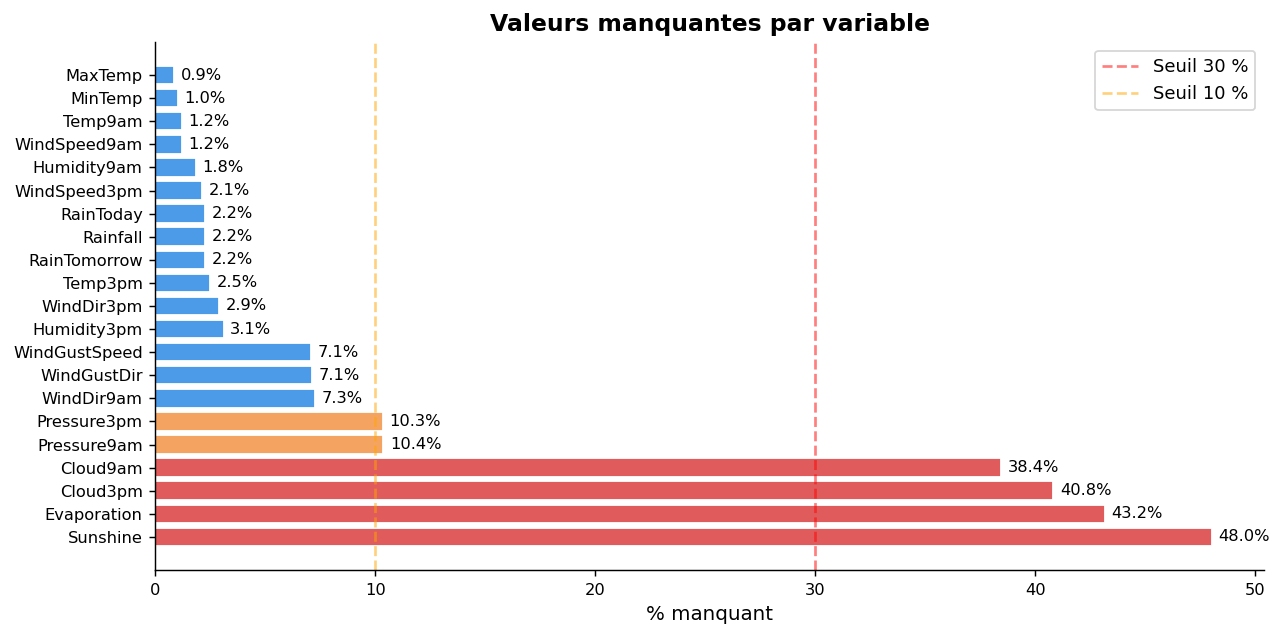

In [14]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=['#E05C5C' if v > 30 else '#F4A460' if v > 10 else '#4C9BE8'
                      for v in missing_pct.values],
               edgecolor='white')
for bar, v in zip(bars, missing_pct.values):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=9)
ax.axvline(30, color='red', linestyle='--', alpha=0.5, label='Seuil 30 %')
ax.axvline(10, color='orange', linestyle='--', alpha=0.5, label='Seuil 10 %')
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par variable', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/fig_missing.png', bbox_inches='tight')
plt.show()

### 2.3 Distributions des variables numériques

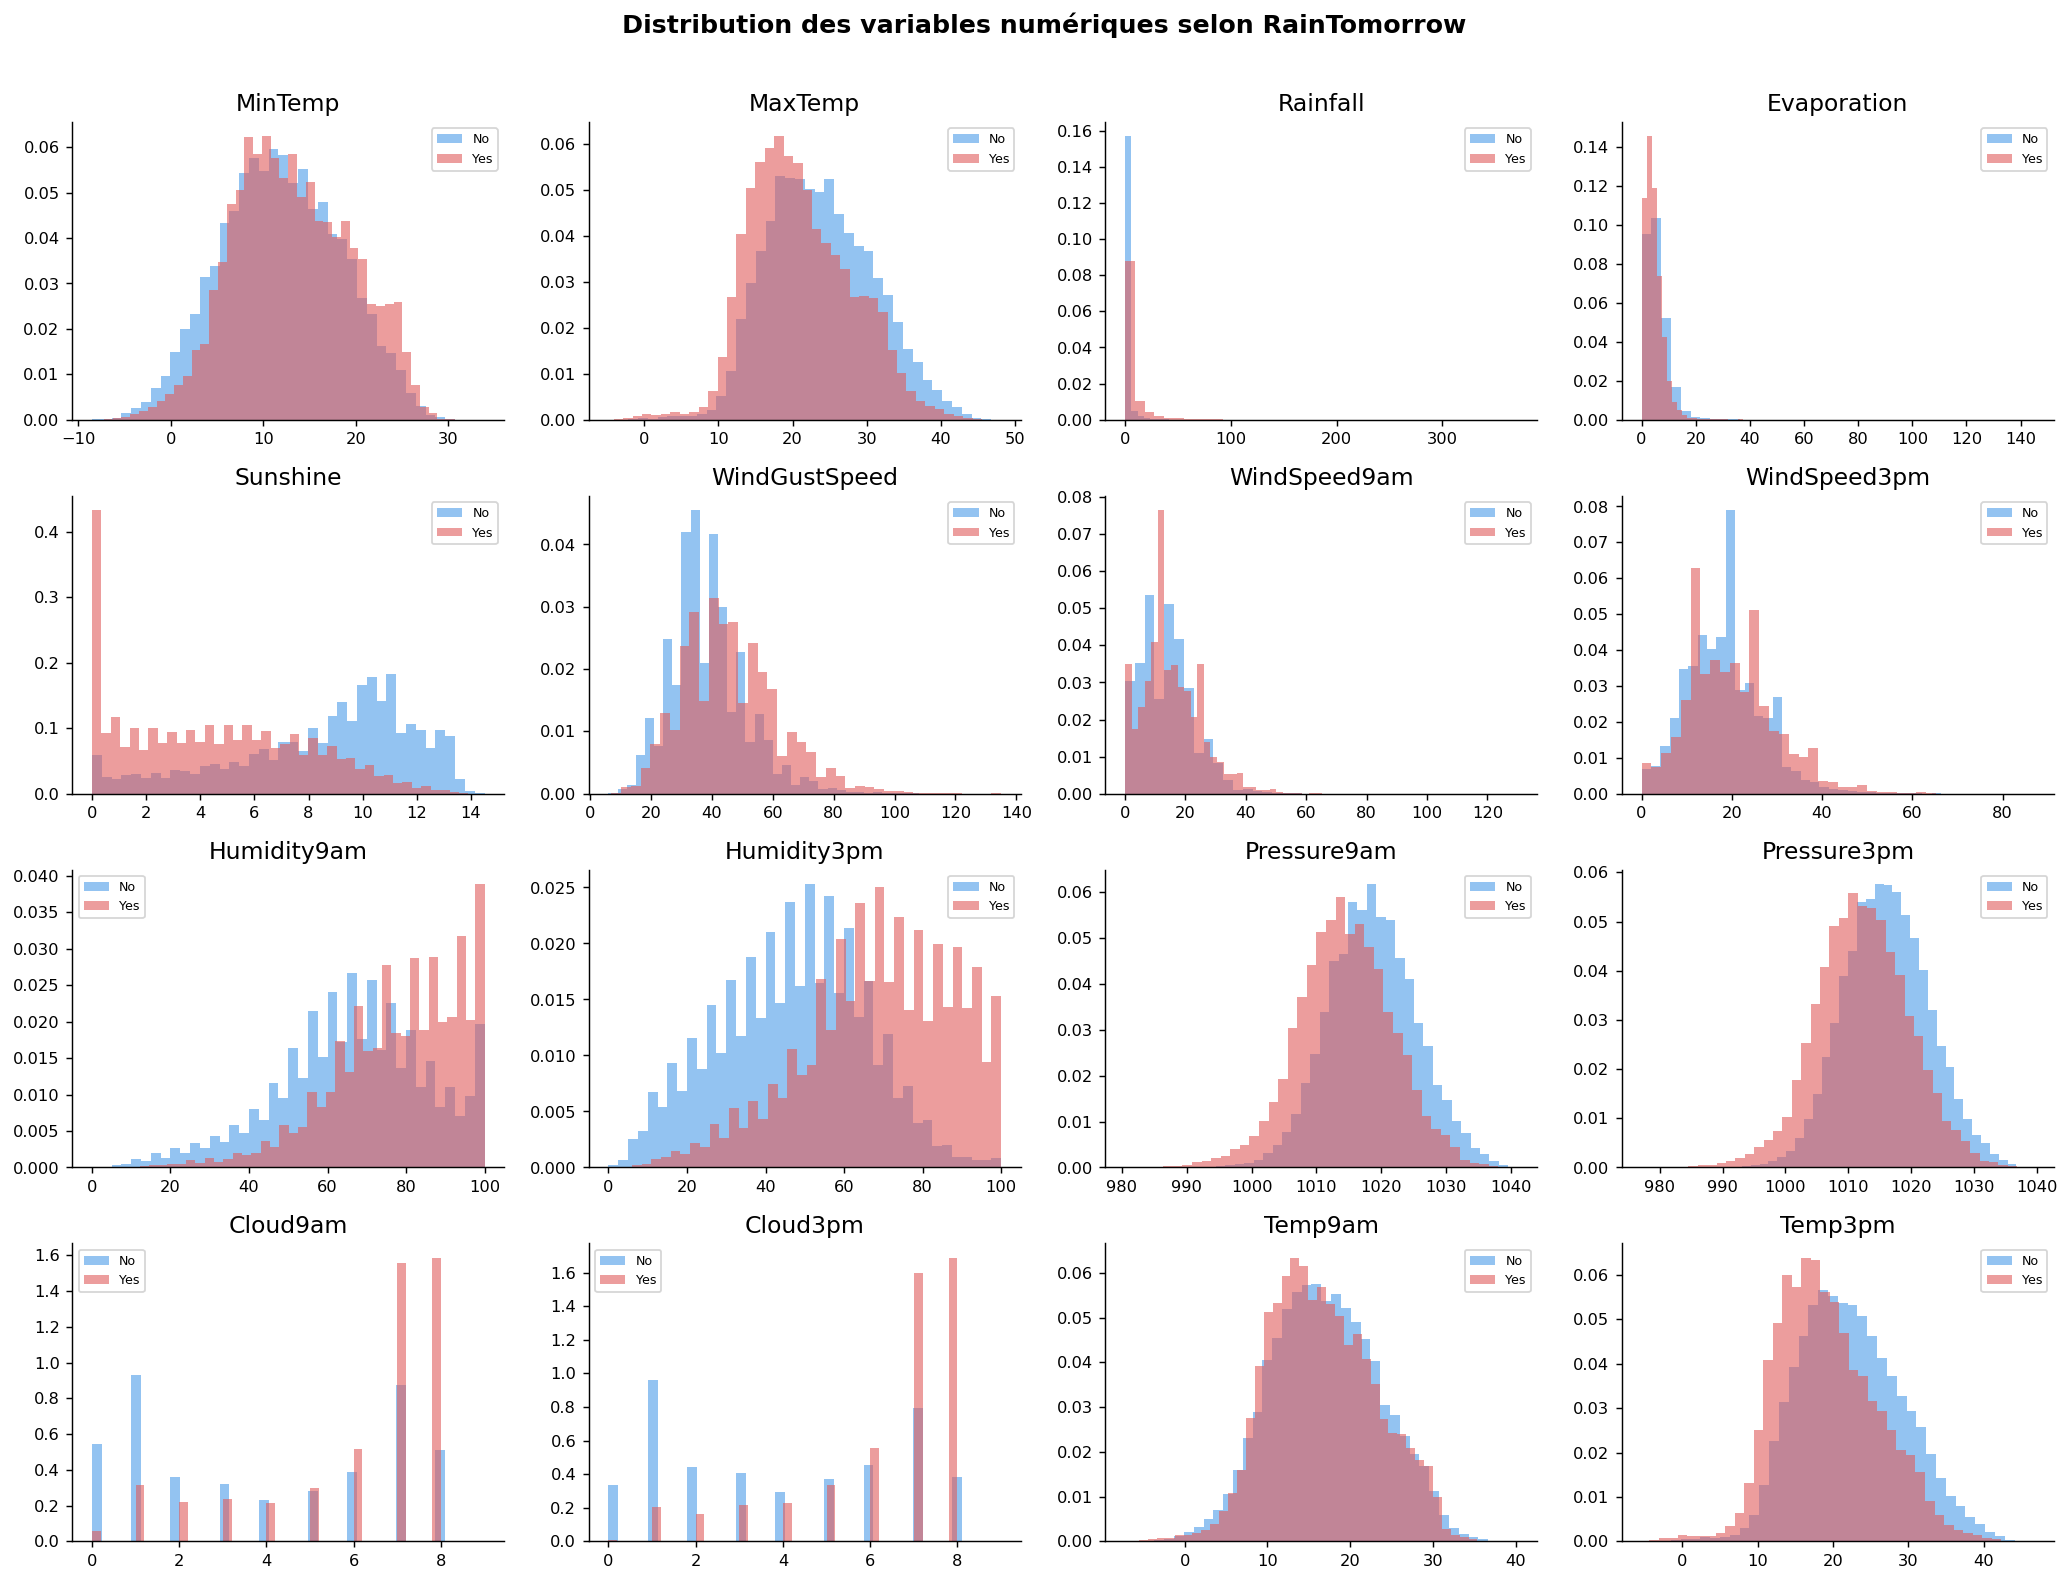

In [15]:
num_cols = df.select_dtypes(include='number').columns.tolist()

n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_no  = df.loc[df['RainTomorrow'] == 'No',  col].dropna()
    data_yes = df.loc[df['RainTomorrow'] == 'Yes', col].dropna()
    axes[i].hist(data_no,  bins=40, alpha=0.6, color=PALETTE['No'],  label='No',  density=True)
    axes[i].hist(data_yes, bins=40, alpha=0.6, color=PALETTE['Yes'], label='Yes', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution des variables numériques selon RainTomorrow',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('artifacts/fig_distributions.png', bbox_inches='tight')
plt.show()

### 2.4 Matrice de corrélation

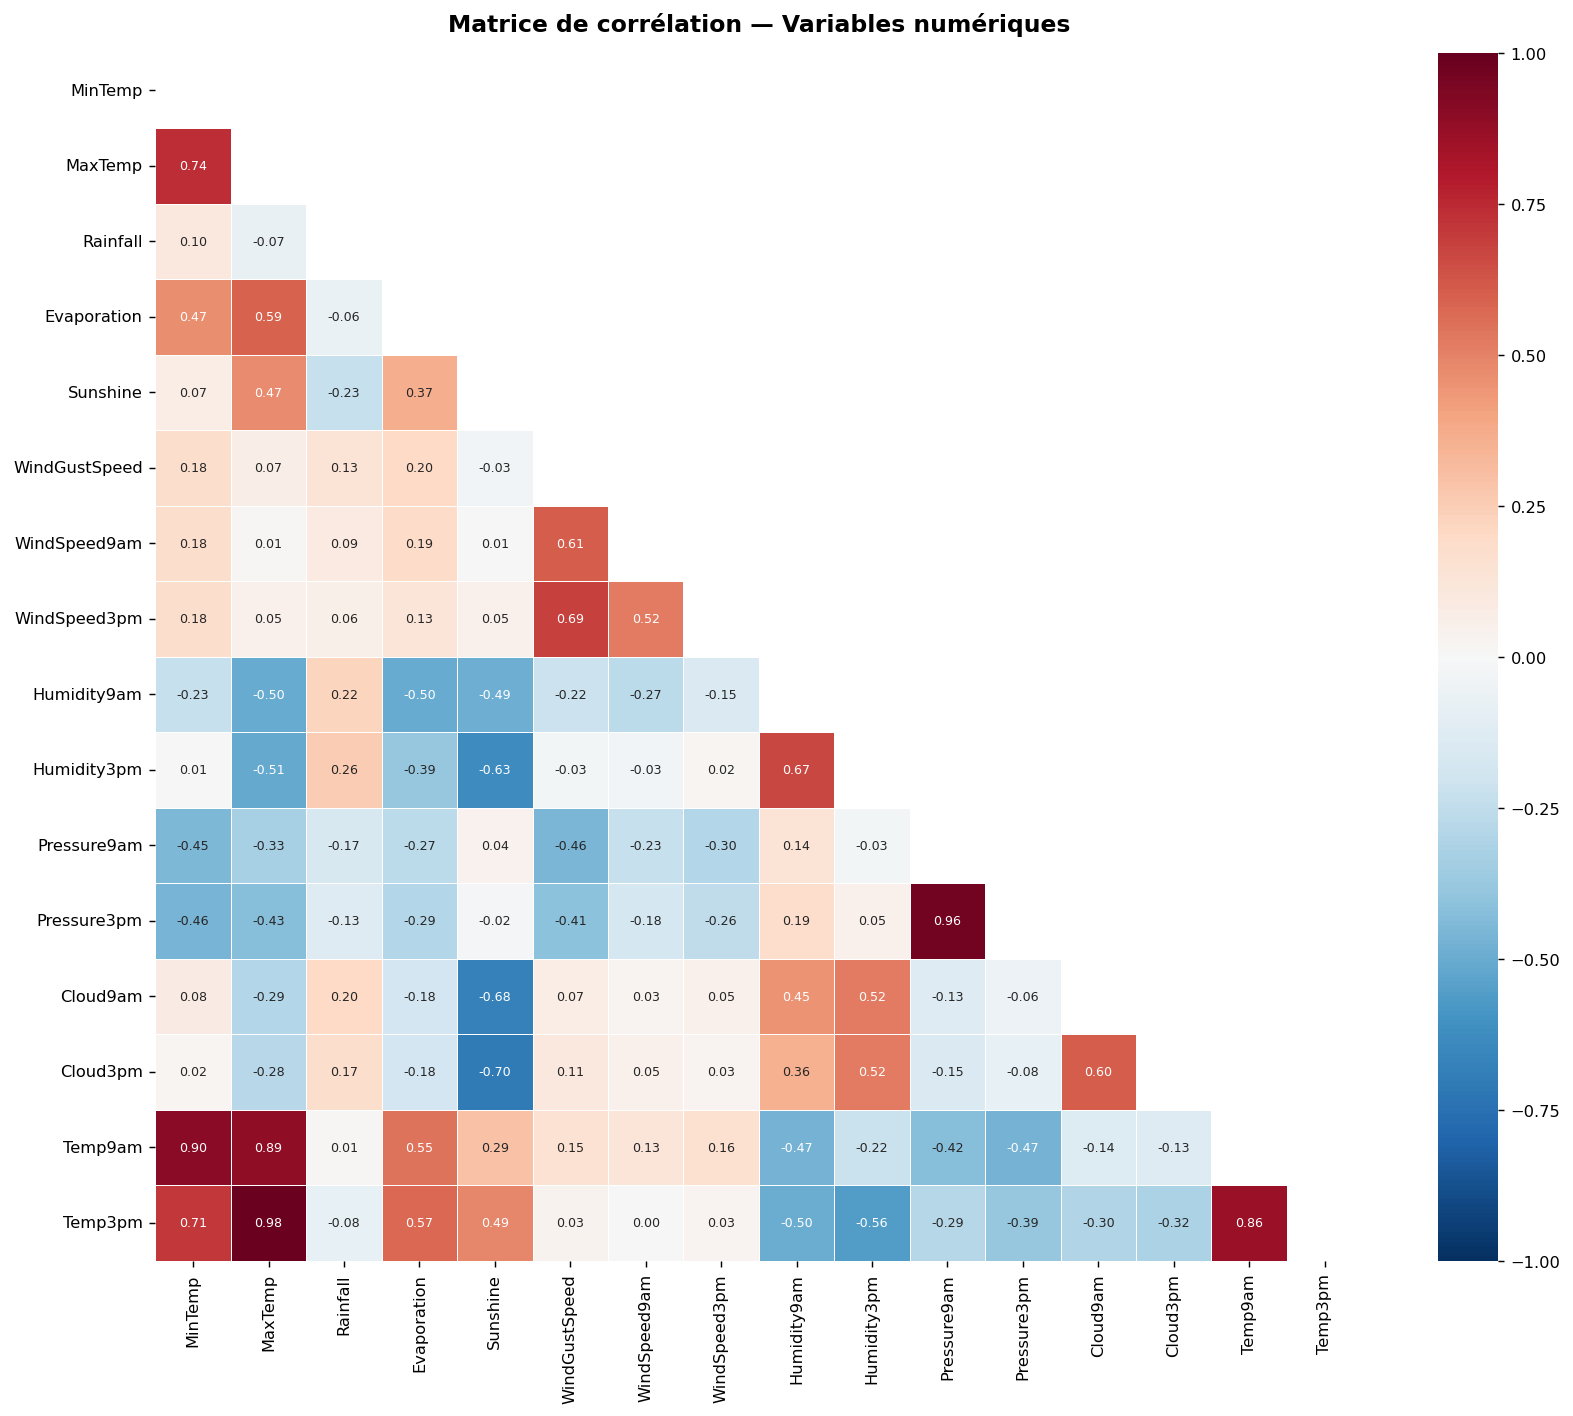

In [16]:
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Matrice de corrélation — Variables numériques', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('artifacts/fig_correlation.png', bbox_inches='tight')
plt.show()

### 2.5 Variables catégorielles

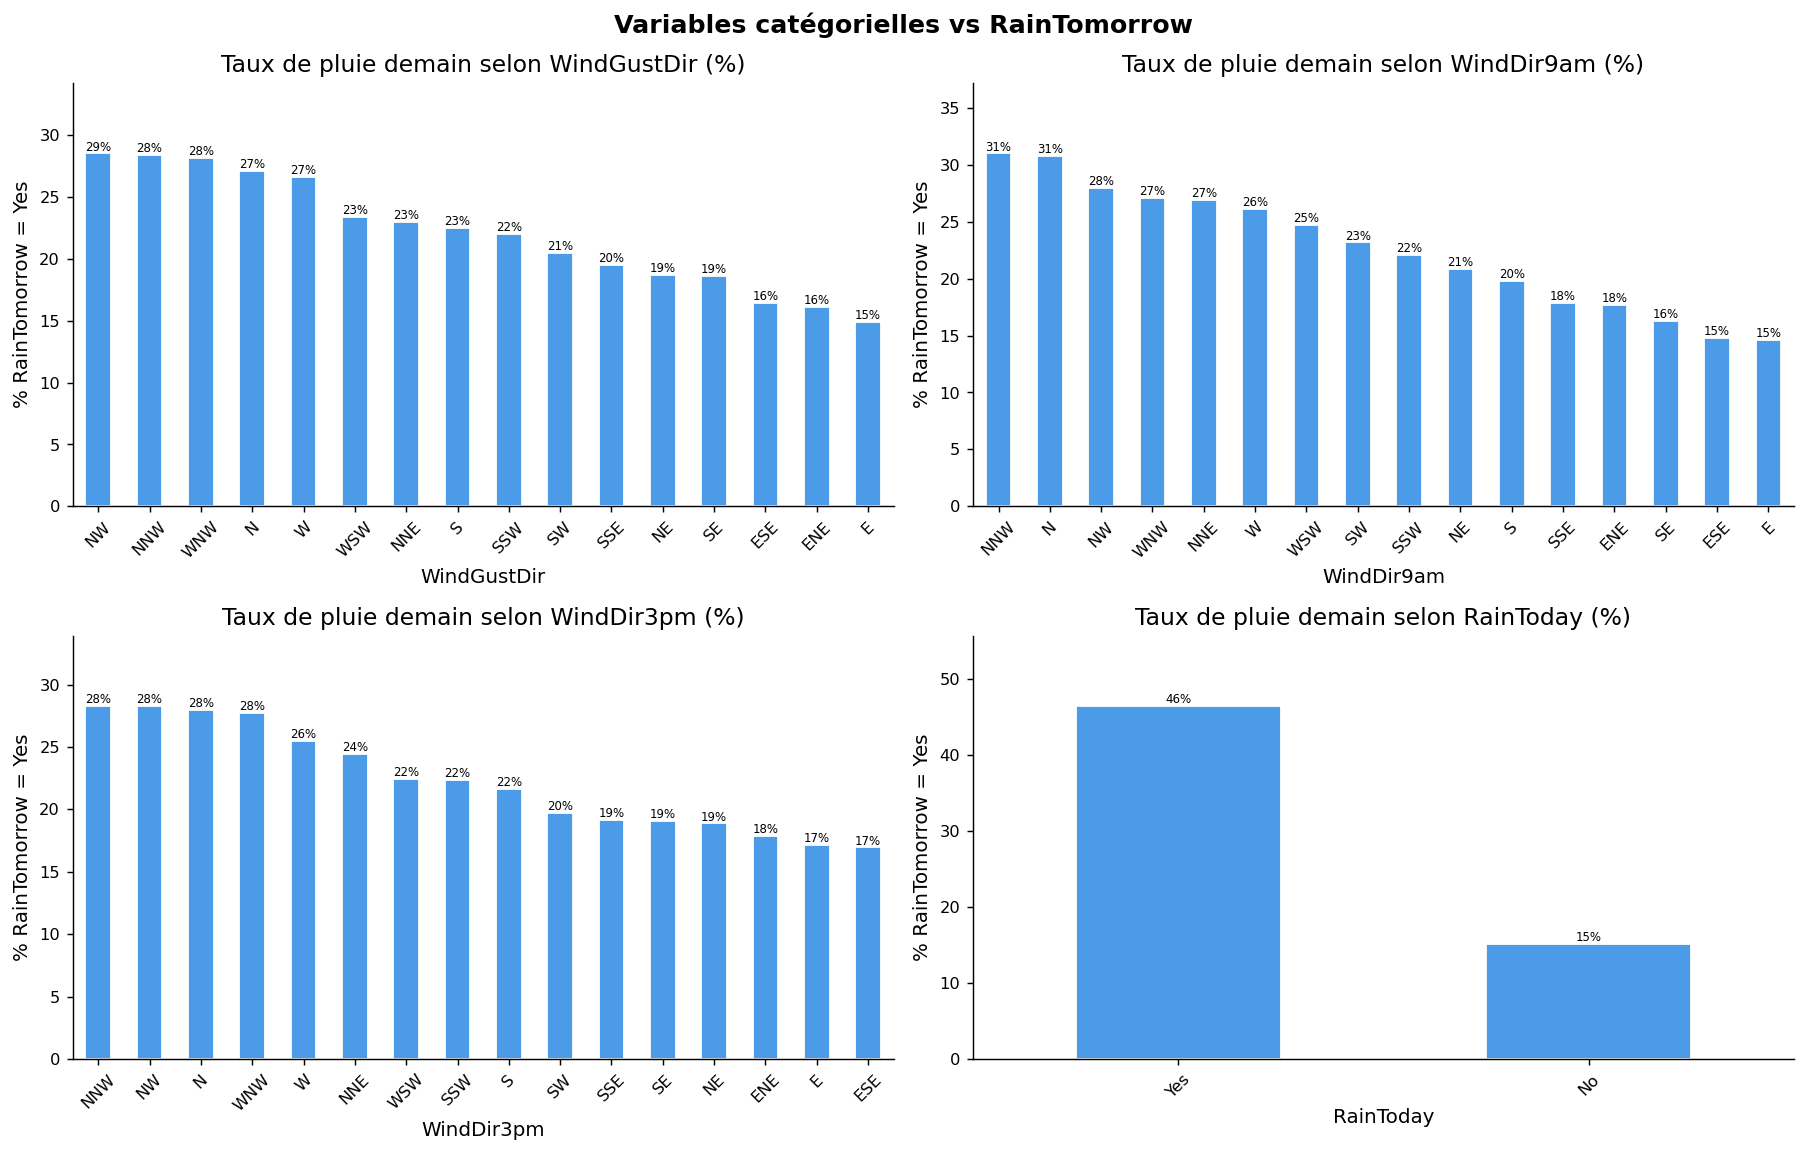

In [17]:
cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rain_rate = (df.groupby(col)['RainTomorrow']
                   .apply(lambda x: (x == 'Yes').sum() / x.notna().sum() * 100)
                   .sort_values(ascending=False))
    rain_rate.plot(kind='bar', ax=axes[i], color='#4C9BE8', edgecolor='white')
    axes[i].set_title(f'Taux de pluie demain selon {col} (%)')
    axes[i].set_ylabel('% RainTomorrow = Yes')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, rain_rate.max() * 1.2)
    for bar in axes[i].patches:
        axes[i].annotate(f'{bar.get_height():.0f}%',
                         (bar.get_x() + bar.get_width()/2, bar.get_height()),
                         ha='center', va='bottom', fontsize=6.5)

fig.suptitle('Variables catégorielles vs RainTomorrow', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/fig_categorical.png', bbox_inches='tight')
plt.show()

### 2.6 Évolution temporelle & saisonnalité

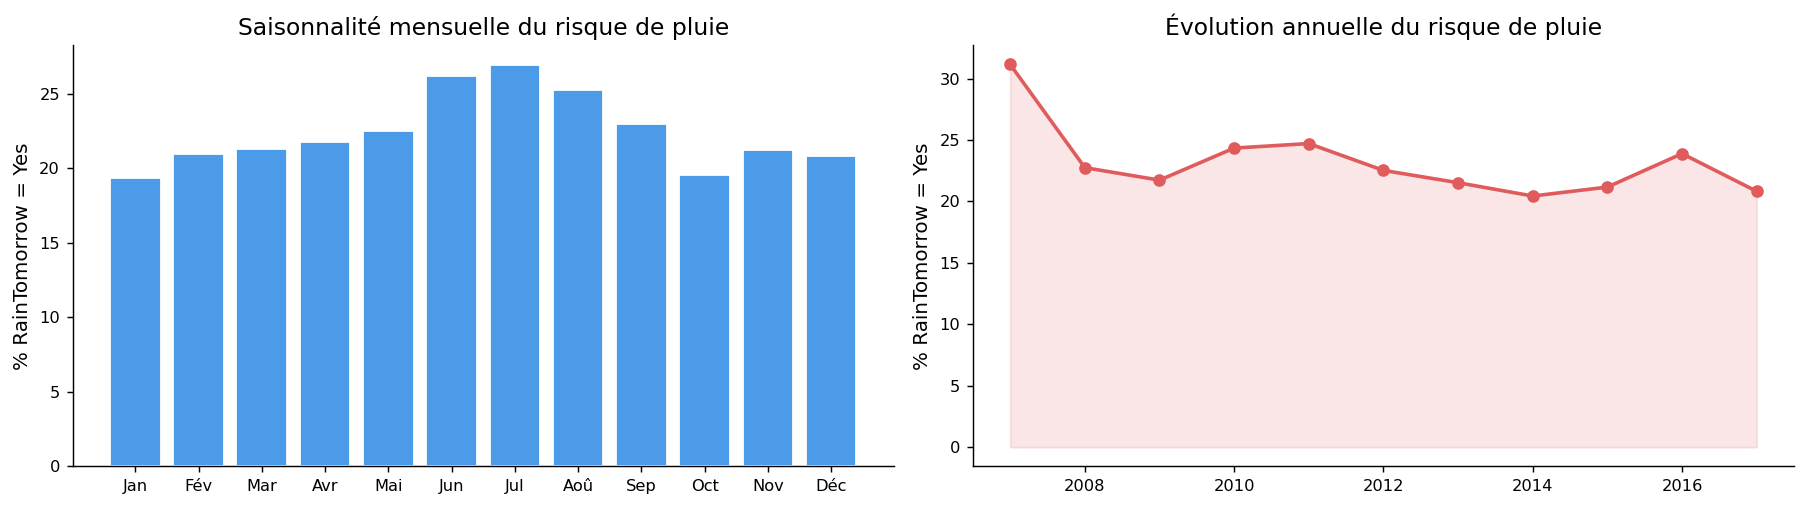

In [18]:
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly = (df.groupby('Month')['RainTomorrow']
             .apply(lambda x: (x == 'Yes').sum() / x.notna().sum() * 100))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Saisonnalité mensuelle
axes[0].bar(monthly.index, monthly.values, color='#4C9BE8', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun',
                          'Jul','Aoû','Sep','Oct','Nov','Déc'])
axes[0].set_ylabel('% RainTomorrow = Yes')
axes[0].set_title('Saisonnalité mensuelle du risque de pluie')

# Taux annuel
yearly = (df.groupby('Year')['RainTomorrow']
            .apply(lambda x: (x == 'Yes').sum() / x.notna().sum() * 100))
axes[1].plot(yearly.index, yearly.values, marker='o', color='#E05C5C', linewidth=2)
axes[1].fill_between(yearly.index, yearly.values, alpha=0.15, color='#E05C5C')
axes[1].set_ylabel('% RainTomorrow = Yes')
axes[1].set_title('Évolution annuelle du risque de pluie')

plt.tight_layout()
plt.savefig('artifacts/fig_temporal.png', bbox_inches='tight')
plt.show()

### 2.7 Top 10 villes les plus pluvieuses

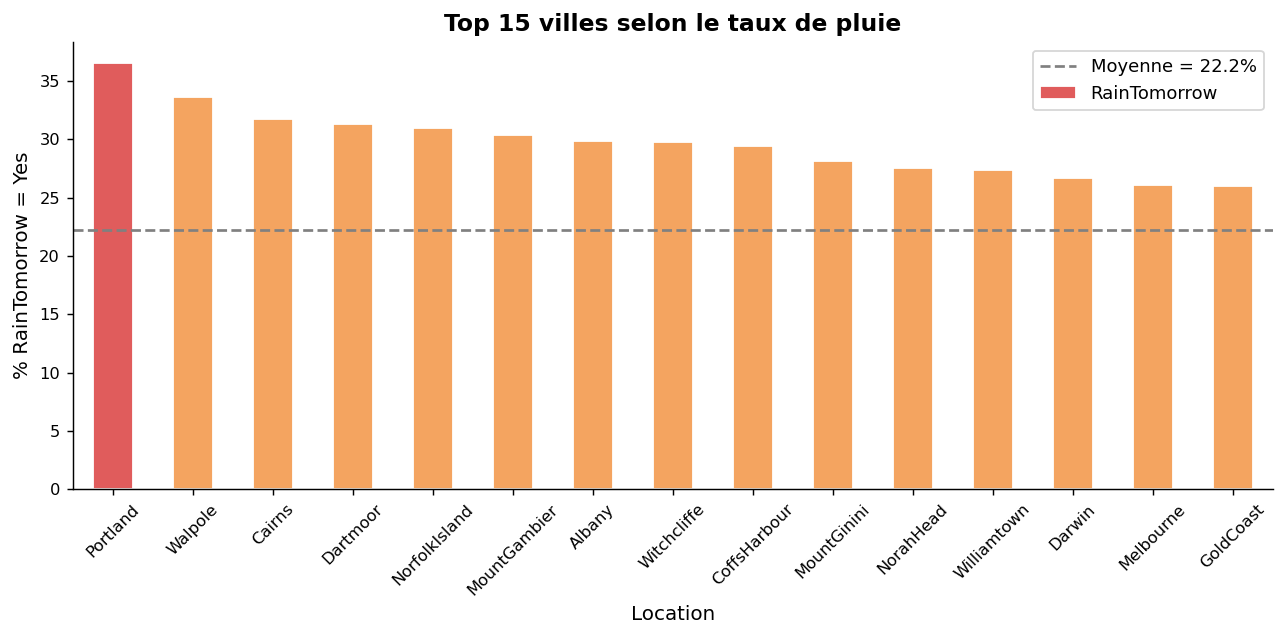

In [19]:
city_rain = (df.groupby('Location')['RainTomorrow']
               .apply(lambda x: (x=='Yes').sum() / x.notna().sum() * 100)
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E05C5C' if v > 35 else '#F4A460' if v > 25 else '#4C9BE8'
          for v in city_rain.head(15).values]
city_rain.head(15).plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_ylabel('% RainTomorrow = Yes')
ax.set_title('Top 15 villes selon le taux de pluie', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.axhline(city_rain.mean(), color='grey', linestyle='--', label=f'Moyenne = {city_rain.mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/fig_cities.png', bbox_inches='tight')
plt.show()

---
## 3. Traitement des valeurs manquantes

In [20]:
print("=" * 55)
print("AVANT traitement")
print(f"  Lignes     : {df.shape[0]:,}")
print(f"  Colonnes   : {df.shape[1]}")
print(f"  Valeurs NaN: {df.isna().sum().sum():,}  ({df.isna().mean().mean()*100:.1f}% du total)")
print("=" * 55)

AVANT traitement
  Lignes     : 145,460
  Colonnes   : 25
  Valeurs NaN: 343,248  (9.4% du total)


### 3.1 Suppression des lignes sans cible

In [21]:
df.dropna(subset=['RainTomorrow'], inplace=True)
print(f"Après suppression des NaN sur RainTomorrow : {df.shape[0]:,} lignes")

Après suppression des NaN sur RainTomorrow : 142,193 lignes


### 3.2 Suppression des colonnes trop lacunaires (> 40 %)

In [22]:
THRESHOLD = 0.40
miss_rate = df.isna().mean()
cols_to_drop = miss_rate[miss_rate > THRESHOLD].index.tolist()
print(f"Colonnes supprimées (>{THRESHOLD*100:.0f}% NaN) : {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)
print(f"Colonnes restantes : {df.shape[1]}")

Colonnes supprimées (>40% NaN) : ['Evaporation', 'Sunshine', 'Cloud3pm']
Colonnes restantes : 22


### 3.3 Imputation des variables numériques (médiane par ville)

In [23]:
num_cols = df.select_dtypes(include='number').columns.tolist()
# Exclure les colonnes temporaires Year/Month si déjà créées
num_fill = [c for c in num_cols if c not in ['Year', 'Month']]

# Imputation par la médiane de la ville (meilleure que la médiane globale)
for col in num_fill:
    df[col] = df.groupby('Location')[col].transform(lambda x: x.fillna(x.median()))

# Si certaines villes n'ont que des NaN pour une col → médiane globale
for col in num_fill:
    global_median = df[col].median()
    df[col].fillna(global_median, inplace=True)

print("✅ Variables numériques imputées (médiane par ville)")
print(f"   NaN restants (num) : {df[num_fill].isna().sum().sum()}")

✅ Variables numériques imputées (médiane par ville)
   NaN restants (num) : 0


### 3.4 Imputation des variables catégorielles (mode par ville)

In [24]:
cat_cols_all = df.select_dtypes(include='object').columns.tolist()
cat_fill = [c for c in cat_cols_all if c not in ['RainTomorrow', 'Date', 'Location']]

for col in cat_fill:
    df[col] = df.groupby('Location')[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )

# Fallback global
for col in cat_fill:
    if df[col].isna().any():
        df[col].fillna(df[col].mode().iloc[0], inplace=True)

print("✅ Variables catégorielles imputées (mode par ville)")
print(f"   NaN restants total : {df.isna().sum().sum()}")

✅ Variables catégorielles imputées (mode par ville)
   NaN restants total : 0


In [25]:
# Vérification visuelle
miss_after = df.isna().sum()
print("\nValeurs manquantes après imputation :")
print(miss_after[miss_after > 0] if miss_after.sum() > 0 else "  ✅ Aucune valeur manquante !")


Valeurs manquantes après imputation :
  ✅ Aucune valeur manquante !


---
## 4. Feature Engineering

> Création de nouvelles variables météo pertinentes pour la prédiction de la pluie.

### 4.1 Features temporelles

In [26]:
df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['DayOfYear']   = df['Date'].dt.dayofyear
df['WeekOfYear']  = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']     = df['Date'].dt.quarter

# Saison australienne (été = Dec–Fév dans l'hémisphère sud)
def get_season(month):
    if month in [12, 1, 2]:  return 'Summer'
    elif month in [3, 4, 5]: return 'Autumn'
    elif month in [6, 7, 8]: return 'Winter'
    else:                    return 'Spring'

df['Season'] = df['Month'].apply(get_season)

# Encodage cyclique du mois et du jour de l'année (pour capturer la périodicité)
df['Month_sin']  = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos']  = np.cos(2 * np.pi * df['Month'] / 12)
df['Day_sin']    = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['Day_cos']    = np.cos(2 * np.pi * df['DayOfYear'] / 365)

print("✅ Features temporelles créées")
print(df[['Month', 'Season', 'Month_sin', 'Month_cos']].head(3))

✅ Features temporelles créées
   Month  Season     Month_sin  Month_cos
0     12  Summer -2.449294e-16        1.0
1     12  Summer -2.449294e-16        1.0
2     12  Summer -2.449294e-16        1.0


### 4.2 Features de température

In [27]:
# Amplitude thermique journalière
df['TempRange']     = df['MaxTemp'] - df['MinTemp']

# Température moyenne journalière
df['TempMean']      = (df['MaxTemp'] + df['MinTemp']) / 2

# Écart entre temp 9h et temp 3h (indicateur du gradient de la journée)
df['TempDiff_9_3']  = df['Temp3pm'] - df['Temp9am']

# Température ressentie (Wind Chill simplifié)
df['WindChill9am']  = 13.12 + 0.6215 * df['Temp9am']  - 11.37 * df['WindSpeed9am']**0.16  + 0.3965 * df['Temp9am']  * df['WindSpeed9am']**0.16
df['WindChill3pm']  = 13.12 + 0.6215 * df['Temp3pm']  - 11.37 * df['WindSpeed3pm']**0.16  + 0.3965 * df['Temp3pm']  * df['WindSpeed3pm']**0.16

print("✅ Features de température créées")
print(df[['TempRange', 'TempMean', 'TempDiff_9_3']].describe().round(2))

✅ Features de température créées


       TempRange   TempMean  TempDiff_9_3
count  142193.00  142193.00     142193.00
mean       11.04      17.71          4.75
std         4.96       6.29          3.60
min        -5.80      -6.15        -13.60
25%         7.20      13.00          2.10
50%        10.40      17.40          4.40
75%        14.50      22.30          7.20
max        32.00      38.80         25.40


### 4.3 Features d'humidité & pression

In [28]:
# Variation d'humidité dans la journée
df['HumidityChange'] = df['Humidity3pm'] - df['Humidity9am']

# Humidité moyenne
df['HumidityMean']   = (df['Humidity9am'] + df['Humidity3pm']) / 2

# Variation de pression
df['PressureChange'] = df['Pressure3pm'] - df['Pressure9am']

# Pression moyenne
df['PressureMean']   = (df['Pressure9am'] + df['Pressure3pm']) / 2

# Point de rosée approché : Temp - (100 - Humidity) / 5
df['DewPoint9am']    = df['Temp9am']  - (100 - df['Humidity9am'])  / 5
df['DewPoint3pm']    = df['Temp3pm']  - (100 - df['Humidity3pm'])  / 5

# Indice de chaleur humide (Heat Index simplifié)
df['HeatIndex9am']   = df['Temp9am']  + 0.33 * (df['Humidity9am']  / 100 * 6.105 * np.exp(17.27 * df['Temp9am']  / (237.7 + df['Temp9am']))) - 4
df['HeatIndex3pm']   = df['Temp3pm']  + 0.33 * (df['Humidity3pm']  / 100 * 6.105 * np.exp(17.27 * df['Temp3pm']  / (237.7 + df['Temp3pm']))) - 4

print("✅ Features humidité & pression créées")

✅ Features humidité & pression créées


### 4.4 Features de vent

In [29]:
# Encodage cyclique des directions de vent (variable circulaire)
DIR_MAP = {'N':0,'NNE':22.5,'NE':45,'ENE':67.5,'E':90,'ESE':112.5,'SE':135,'SSE':157.5,
           'S':180,'SSW':202.5,'SW':225,'WSW':247.5,'W':270,'WNW':292.5,'NW':315,'NNW':337.5}

for col, suffix in [('WindGustDir', 'Gust'), ('WindDir9am', '9am'), ('WindDir3pm', '3pm')]:
    if col in df.columns:
        deg = df[col].map(DIR_MAP).fillna(0)
        df[f'WindDir{suffix}_sin'] = np.sin(np.deg2rad(deg))
        df[f'WindDir{suffix}_cos'] = np.cos(np.deg2rad(deg))

# Variation de vitesse de vent
df['WindSpeedChange'] = df['WindSpeed3pm'] - df['WindSpeed9am']

# Vitesse de vent moyenne
df['WindSpeedMean']   = (df['WindSpeed9am'] + df['WindSpeed3pm']) / 2

# Indicateur tempête (rafales > 60 km/h)
if 'WindGustSpeed' in df.columns:
    df['StormFlag'] = (df['WindGustSpeed'] > 60).astype(int)

print("✅ Features de vent créées")

✅ Features de vent créées


### 4.5 Features d'interaction & indicateurs synthétiques

In [30]:
# Score de risque de pluie heuristique (combine humidité élevée + pression basse + pluie aujourd'hui)
df['RainToday_bin'] = (df['RainToday'] == 'Yes').astype(int)

df['RainRiskScore'] = (
    df['HumidityMean'] / 100 * 0.4
    + (1 - (df['PressureMean'] - 990) / (1040 - 990)).clip(0, 1) * 0.35
    + df['RainToday_bin'] * 0.25
)

# Interaction : humidité × nuages
if 'Cloud9am' in df.columns and 'Cloud3pm' in df.columns:
    df['CloudMean']             = (df['Cloud9am'] + df['Cloud3pm']) / 2
    df['HumidityCloud_product'] = df['HumidityMean'] * df['CloudMean']

# Interaction : température × humidité (sensation inconfort)
df['TempHumidity_interact'] = df['TempMean'] * df['HumidityMean']

# Variable ensoleillement disponible ?
if 'Sunshine' in df.columns:
    df['LowSunshine'] = (df['Sunshine'] < 4).astype(int)

print("✅ Features d'interaction créées")

✅ Features d'interaction créées


### 4.6 Features de lag (glissement temporel par ville)

In [31]:
df.sort_values(['Location', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)

lag_cols = ['Rainfall', 'Humidity3pm', 'MaxTemp', 'MinTemp']

for col in lag_cols:
    if col in df.columns:
        g = df.groupby('Location')[col]
        df[f'{col}_lag1'] = g.shift(1)   # Jour J-1
        df[f'{col}_lag2'] = g.shift(2)   # Jour J-2
        df[f'{col}_lag7'] = g.shift(7)   # Semaine précédente
        df[f'{col}_roll3'] = g.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())  # Moyenne mobile 3j
        df[f'{col}_roll7'] = g.transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())  # Moyenne mobile 7j

# Remplir les NaN créés par les lags (premières lignes de chaque ville)
lag_feat_cols = [c for c in df.columns if '_lag' in c or '_roll' in c]
df[lag_feat_cols] = df[lag_feat_cols].fillna(method='bfill').fillna(0)

print(f"✅ {len(lag_feat_cols)} features de lag/rolling créées")
print(df[[f'{lag_cols[0]}_lag1', f'{lag_cols[0]}_roll7']].head(4))

✅ 20 features de lag/rolling créées
   Rainfall_lag1  Rainfall_roll7
0            5.0        5.000000
1            5.0        5.000000
2            0.8        2.900000
3            0.0        1.933333


### 4.7 Encodage des variables catégorielles

In [32]:
# Encoder la cible
df['RainTomorrow_enc'] = (df['RainTomorrow'] == 'Yes').astype(int)

# Encodage des directions (déjà encodées cycliquement → on peut supprimer les colonnes texte)
dirs_to_drop = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
df.drop(columns=[c for c in dirs_to_drop if c in df.columns], inplace=True)

# One-Hot Encoding : Saison, RainToday
df = pd.get_dummies(df, columns=['Season', 'RainToday'], drop_first=True)

# Target Encoding : Location (taux de pluie par ville)
loc_rain_rate = df.groupby('Location')['RainTomorrow_enc'].mean()
df['Location_rainrate'] = df['Location'].map(loc_rain_rate)
# NOTE: Location column is preserved (not dropped) for downstream use\n
# (filtering by city, display, etc.). Models use Location_rainrate as the numeric feature.\n

print("✅ Encodage terminé")
print(f"   Shape final : {df.shape}")

✅ Encodage terminé
   Shape final : (142193, 76)


---
## 5. Résumé & Dataset final

In [33]:
# Colonnes à exclure du modèle (identifiants, cible brute)
EXCLUDE = ['Date', 'RainTomorrow', 'Year', 'Location']  # Year gardé dans DayOfYear

feature_cols = [c for c in df.columns if c not in EXCLUDE + ['RainTomorrow_enc']]
X = df[feature_cols]
y = df['RainTomorrow_enc']

print("=" * 55)
print("DATASET FINAL")
print(f"  Lignes      : {X.shape[0]:,}")
print(f"  Features    : {X.shape[1]}")
print(f"  Cible       : RainTomorrow_enc  (0/1)")
print(f"  Class 0 (No): {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)")
print(f"  Class 1 (Yes): {(y==1).sum():,}  ({(y==1).mean()*100:.1f}%)")
print("=" * 55)

# Vérification finale
assert X.isna().sum().sum() == 0, "⚠️ Il reste des NaN dans X !"
print("✅ Aucune valeur manquante dans le dataset final !")

DATASET FINAL
  Lignes      : 142,193
  Features    : 71
  Cible       : RainTomorrow_enc  (0/1)
  Class 0 (No): 110,316  (77.6%)
  Class 1 (Yes): 31,877  (22.4%)
✅ Aucune valeur manquante dans le dataset final !


In [34]:
# Liste et catégories des features finales
feat_df = pd.DataFrame({
    'Feature'  : feature_cols,
    'Dtype'    : [X[c].dtype for c in feature_cols],
    'Std'      : [X[c].std() if X[c].dtype != 'bool' else 0.5 for c in feature_cols],
})

def categorize(name):
    if any(k in name for k in ['lag', 'roll'])          : return '🕐 Lag/Rolling'
    if any(k in name for k in ['sin','cos','Month','Day','Week','Quarter','Season']): return '📅 Temporelle'
    if any(k in name for k in ['Temp','WindChill','HeatIndex','DewPoint']): return '🌡️ Température'
    if any(k in name for k in ['Humid','Dew','Rain'])   : return '💧 Humidité/Pluie'
    if any(k in name for k in ['Pressure'])             : return '🌐 Pression'
    if any(k in name for k in ['Wind','Storm'])         : return '💨 Vent'
    if any(k in name for k in ['Cloud','Sunshine','Sun','Low']): return '☁️ Nuages/Soleil'
    if any(k in name for k in ['interact','product','Score','Location']): return '🔗 Interaction'
    return '📦 Autre'

feat_df['Catégorie'] = feat_df['Feature'].apply(categorize)

print("\nRépartition des features par catégorie :")
print(feat_df.groupby('Catégorie').size().sort_values(ascending=False).to_string())
print(f"\nTotal : {len(feature_cols)} features")


Répartition des features par catégorie :
Catégorie
🕐 Lag/Rolling       21
📅 Temporelle        17
🌡️ Température      14
💧 Humidité/Pluie     8
💨 Vent               5
🌐 Pression           4
☁️ Nuages/Soleil     1
🔗 Interaction        1

Total : 71 features


In [35]:
# Sauvegarde
# Include Location column for downstream use (city filtering, display)
df_final = pd.concat([df['Location'].reset_index(drop=True), X, y], axis=1)
df_final.to_csv('weatherAUS_clean_features.csv', index=False)
print("✅ Dataset sauvegardé : weatherAUS_clean_features.csv")
print(f"   Taille : {df_final.shape}")

✅ Dataset sauvegardé : weatherAUS_clean_features.csv
   Taille : (142193, 73)


---
## Résumé des étapes réalisées

| Étape | Détail |
|-------|--------|
| **EDA** | Distribution cible, heatmap NaN, distributions par classe, corrélations, saisonnalité, top villes |
| **Nettoyage** | Suppression des lignes sans cible, drop colonnes >40% NaN, imputation médiane/mode par ville |
| **Features temporelles** | Year, Month, DayOfYear, Quarter, Season (hémisphère sud), encodage cyclique sin/cos |
| **Features température** | TempRange, TempMean, TempDiff_9_3, WindChill, HeatIndex |
| **Features humidité/pression** | HumidityChange/Mean, PressureChange/Mean, DewPoint, HeatIndex |
| **Features vent** | Encodage cyclique des directions, WindSpeedChange/Mean, StormFlag |
| **Interactions** | RainRiskScore, HumidityCloud, TempHumidity, LowSunshine |
| **Lags/Rolling** | lag1, lag2, lag7 + rolling 3j et 7j sur Rainfall, Humidity, Temp |
| **Encodage** | OHE (Season, RainToday) + Target Encoding (Location → Location_rainrate) + cible binaire. Location conservé pour filtrage. |